I tried the following:
1. Downloaded the dataset from Kaggle
2. Categorized the dataset into fruits and vegetables because all the fruits and vegetables are mixed together under train, test and validation folders
3. Finally zipped the folder and uploaded manually into Colab using the Files upload option

But the above resulted in an error showing that I have not uploaded the zipped folder eventhough I uploaded the ziped folder.

Also tried the files.upload() but this was taking more time for upload.

This made me to use the Kaggle API and I did the following,
1. I generated an API token in Kaggle under my account
2. Then I imported it in the Colab

STEP 1: Set Kaggle API Token

In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = "TOKEN"

# I have removed the API token generateSd from this code line
# This I removed after completing and saving the model
# This I have done as part of security and to avoid misuse

STEP 2: Install Kaggle

In [ ]:
!pip install kaggle

STEP 3: Download Dataset

In [ ]:
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition

Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
100% 1.98G/1.98G [00:30<00:00, 69.4MB/s]



STEP 4: Unzip Dataset

In [ ]:
import zipfile

with zipfile.ZipFile('fruit-and-vegetable-image-recognition.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Unzip Done")

Unzip Done


STEP 5: Grouping Fruits & Vegetables

In [ ]:
import os
import shutil

# Original train path
base_dir = '/content/dataset/train'

# New folder for 2 classes
new_dir = '/content/final_data'

os.makedirs(new_dir + '/Fruits', exist_ok=True)
os.makedirs(new_dir + '/Vegetables', exist_ok=True)

# List of fruits (from case study)
fruits = ['banana','apple','pear','grapes','orange','kiwi','watermelon',
          'pomegranate','pineapple','mango']

# Loop through all folders
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)

    if folder.lower() in fruits:
        target = new_dir + '/Fruits'
    else:
        target = new_dir + '/Vegetables'

    # Copy images
    for img in os.listdir(folder_path):
        shutil.copy(os.path.join(folder_path, img), target)

print("Dataset converted to 2 classes - fruits & vegetables")

Dataset converted to 2 classes - fruits & vegetables


STEP 6: Import Libraries

In [ ]:
import os
import glob
import numpy as np

from tensorflow.keras.preprocessing import image
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical

STEP 7: Set Train Folder Path

In [ ]:
base_dir = '/content/final_data'

In [ ]:
# Quick Check after grouping
import os
os.listdir('/content/final_data')

['Fruits', 'Vegetables']

STEP 8: Get Image Paths

In [ ]:
import glob
import os

base_dir = '/content/final_data'

fruit_paths = glob.glob(os.path.join(base_dir, 'Fruits', '*'))
veg_paths   = glob.glob(os.path.join(base_dir, 'Vegetables', '*'))

print("Fruits:", len(fruit_paths))
print("Vegetables:", len(veg_paths))


Fruits: 176
Vegetables: 257


STEP 9: Load Images

In [ ]:
data = []
labels = []

# Fruits → label 0
for path in fruit_paths:
    img = image.load_img(path, target_size=(100,100))
    img_array = image.img_to_array(img) / 255.0
    data.append(img_array)
    labels.append(0)

# Vegetables → label 1
for path in veg_paths:
    img = image.load_img(path, target_size=(100,100))
    img_array = image.img_to_array(img) / 255.0
    data.append(img_array)
    labels.append(1)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


STEP 10: Convert to NumPy

In [ ]:
x = np.array(data)
y = np.array(labels)

print("Data shape:", x.shape)

Data shape: (433, 100, 100, 3)


STEP 11: Convert Labels

In [ ]:
y_cat = to_categorical(y)

# Show y_cat
y_cat

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.

STEP 12: Build Model

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


STEP 13: Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

STEP 14: Train Model

In [ ]:
model.fit(x, y_cat, epochs=10, batch_size=32)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 421ms/step - accuracy: 0.5751 - loss: 0.8097
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 306ms/step - accuracy: 0.5982 - loss: 0.6597
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 344ms/step - accuracy: 0.6744 - loss: 0.6205
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 357ms/step - accuracy: 0.7413 - loss: 0.5482
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.7783 - loss: 0.4612
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 424ms/step - accuracy: 0.8684 - loss: 0.3646
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.8637 - loss: 0.3078
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - accuracy: 0.9122 - loss: 0.2576
Epoch 9/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 425ms/step - accuracy: 0.9492 - loss: 0.1731
Epoch 10/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 309ms/step - accuracy: 0.9261 - loss: 0.1952


STEP 15: Test with New Images

Fruits Test:

Apple

Saving Image_1.jpg to Image_1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: Fruit


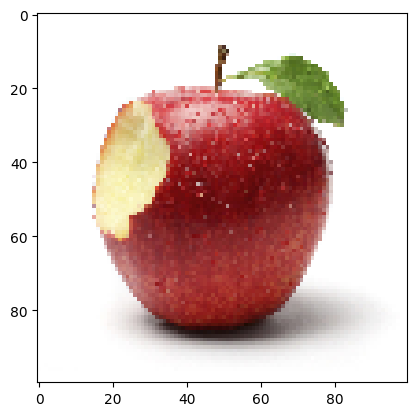

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()

for img_name in uploaded.keys():
    img = image.load_img(img_name, target_size=(100,100))
    plt.imshow(img)

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)

    label = "Fruit" if class_idx == 0 else "Vegetable"
    print("Prediction:", label)

Banana

Saving Image_4.jpg to Image_4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Prediction: Fruit


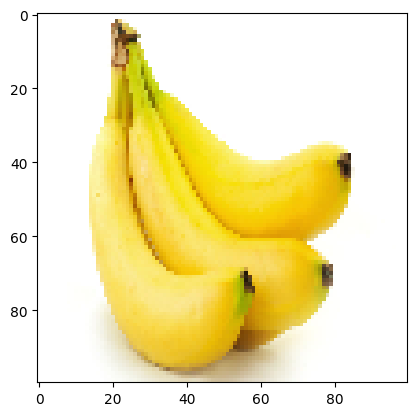

In [ ]:
uploaded = files.upload()

for img_name in uploaded.keys():
    img = image.load_img(img_name, target_size=(100,100))
    plt.imshow(img)

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)

    label = "Fruit" if class_idx == 0 else "Vegetable"
    print("Prediction:", label)

Vegetables Test:

Carrot

Saving Image_2.jpg to Image_2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction: Vegetable


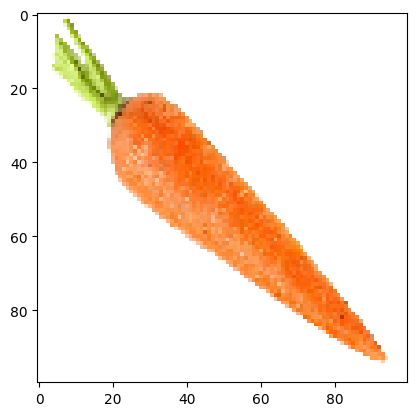

In [ ]:
uploaded = files.upload()

for img_name in uploaded.keys():
    img = image.load_img(img_name, target_size=(100,100))
    plt.imshow(img)

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)

    label = "Fruit" if class_idx == 0 else "Vegetable"
    print("Prediction:", label)

Tomato

Saving Image_7.jpg to Image_7.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: Vegetable


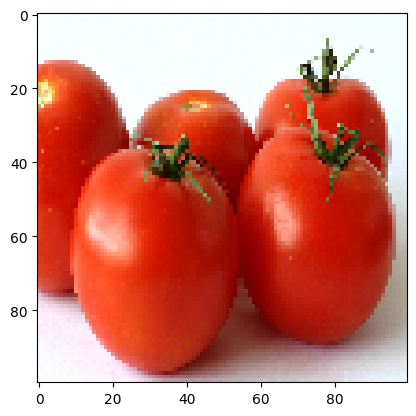

In [ ]:
uploaded = files.upload()

for img_name in uploaded.keys():
    img = image.load_img(img_name, target_size=(100,100))
    plt.imshow(img)

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)

    label = "Fruit" if class_idx == 0 else "Vegetable"
    print("Prediction:", label)

STEP 15: Save Model

In [ ]:
model.save("fruit_veg_model.keras")